<a href="https://colab.research.google.com/github/kartikeyabekkari/HyperRealisticNisqSimulation/blob/main/Hyper_Realistic_NISQ_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup & Imports



In [ ]:
!pip install --upgrade --force-reinstall cirq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 3.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.7/733.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.

In [ ]:
import warnings
warnings.filterwarnings("ignore")


try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")


import matplotlib.pyplot as plt
import cirq_web
import numpy as np

print("Libraries Imported Successfully!")

Libraries Imported Successfully!




---


#Parameters





In [ ]:
import cirq
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
deg = np.radians

---

In [ ]:
#================ Parameters =================

number_of_qubits_in_the_circuit = 2
number_of_runs = 4096
base_noise = 0 # <---- In Decimal Representation of Percentage
high_noise = 0.027 # <---- In Decimal Representation of Percentage
distance_between_qubits = 2 # <---- In Micro Meters
frequency_overlap = 0 # <---- In Gigahertz

#=============== Build Circuit ===============
qubits = cirq.LineQubit.range(number_of_qubits_in_the_circuit)
base_circuit = cirq.Circuit([

#---------------------------------------------
     cirq.H(qubits[0]),
     cirq.CNOT(qubits[0], qubits[1]),
     cirq.measure(qubits, key='result')
#---------------- Edit Here ^ ----------------

])
#=================== Show ====================

print(f'Your Circuit:\n\n{base_circuit}\n')

Your Circuit:

0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────



#Functions

In [ ]:
def inject_errors(original_circuit):
      noisy_circuit = cirq.Circuit()
      for moment in original_circuit:
        # Add the original operations first
          noisy_circuit.append(moment)

        # Skip noise injection entirely if moment contains a measurement
          if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
              continue

          active_loud_qubits = set()

          for op in moment:
              is_loud_gate = isinstance(op.gate, (
                  cirq.XPowGate,
                  cirq.YPowGate,
                  cirq.ZPowGate,
                  cirq.HPowGate,
                  cirq.CXPowGate,
                  cirq.PhasedXPowGate
              ))

              if is_loud_gate:
                  active_loud_qubits.update(op.qubits)

          error_gates = []
          for q in original_circuit.all_qubits():
              # Sets error to
              error_rate = high_noise if q in active_loud_qubits else base_noise
              error_gates.append(cirq.bit_flip(p=error_rate)(q))

          # Add the error gates to the noisy circuit
          noisy_circuit.append(cirq.Moment(error_gates))

      return noisy_circuit
noisy_circuit = inject_errors(base_circuit)
noisy_circuit

0: ───X───BF(0.027)───M('result')───
                      │
1: ───────BF(0)───────M─────────────
                      │
2: ───────BF(0)───────M─────────────

In [ ]:

def find_errors():
  simulator = cirq.Simulator()
  error_qubit_stream = []
  noisy_moments = list(inject_errors(base_circuit))
    # Store list of moments directly to check what gates are inside




    # Stochastic trajectory sampling replaces the original broken .sample() step here
  for current_moment in noisy_moments:
        is_error_moment = any(isinstance(op.gate, cirq.BitFlipChannel) for op in current_moment)
        if is_error_moment:
            flipped_qubits = []
            for op in current_moment:
                if isinstance(op.gate, cirq.BitFlipChannel):
                    p_val = op.gate.p
                    # FIX: Access the single qubit from the op.qubits tuple
                    q_idx = qubits.index(op.qubits[0])
                    if np.random.rand() < p_val:
                        flipped_qubits.append(q_idx)
            if flipped_qubits:
                error_qubit_stream.append(flipped_qubits)
            else:
                error_qubit_stream.append([])
        else:
            error_qubit_stream.append([])
  return error_qubit_stream, noisy_moments
find_errors()

([[], [], []],
 [cirq.Moment(
      cirq.X(cirq.LineQubit(0)),
  ),
  cirq.Moment(
      cirq.bit_flip(p=0.027).on(cirq.LineQubit(0)),
      cirq.bit_flip(p=0).on(cirq.LineQubit(1)),
      cirq.bit_flip(p=0).on(cirq.LineQubit(2)),
  ),
  cirq.Moment(
      cirq.measure(cirq.LineQubit(0), cirq.LineQubit(1), cirq.LineQubit(2), key=cirq.MeasurementKey(name='result')),
  )])

In [ ]:
def create_final_circuit(original_circuit, qubit_stream, noisy_moments_list):
        building_circuit = cirq.Circuit()
        all_qubits = sorted(list(original_circuit.all_qubits()))
        stream_idx = 0
        for base_step_idx, moment in enumerate(original_circuit):
            building_circuit.append(moment)
            if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
                continue
            detected_flips = 0
            while stream_idx < len(noisy_moments_list) and stream_idx < len(qubit_stream):
                moment_to_check = noisy_moments_list[stream_idx]
                is_error = any(isinstance(op.gate, cirq.BitFlipChannel) for op in moment_to_check)
                if is_error:
                    detected_flips = qubit_stream[stream_idx]
                    stream_idx += 1
                    break
                stream_idx += 1
            crosstalk_noise_gates = []
            for q_idx, qubit in enumerate(all_qubits):
                if isinstance(detected_flips, list) and q_idx in detected_flips:
                    noise_chance = 1.0
                elif isinstance(detected_flips, list) and len(detected_flips) > 0:
                    neighbor_distances = [abs(q_idx - flipped_idx) for flipped_idx in detected_flips]
                    shortest_neighbor_distance = min(neighbor_distances)
                    noise_chance = (
                        1.0 / ((shortest_neighbor_distance*distance_between_qubits)**4)
                    )
                else:
                    noise_chance = 0.0
                crosstalk_noise_gates.append(cirq.bit_flip(p=noise_chance)(qubit))
            building_circuit.append(cirq.Moment(crosstalk_noise_gates))
        return building_circuit

final_circuit = create_final_circuit(base_circuit, error_qubit_stream, noisy_moments)
final_circuit

0: ───X───BF(0)───M('result')───
                  │
1: ───────BF(0)───M─────────────
                  │
2: ───────BF(0)───M─────────────

In [ ]:
total_counts = Counter()
def simulate(type_of_noise):
    sim = cirq.Simulator(noise=type_of_noise)
    result = sim.run(final_circuit)
    run_count = result.histogram(key='result')
    total_counts.update(run_count)


In [ ]:
def Graph():
  print("\n--- SIMULATION RESULTS ---\n")

  total_possible_states = 2**number_of_qubits_in_the_circuit
  labels = []
  values = []
  for outcome in range(total_possible_states):
      binary_string = format(outcome, f"0{number_of_qubits_in_the_circuit}b")
      labels.append(binary_string)
      actual_count = total_counts.get(outcome, 0)
      values.append(actual_count)
      print(f"State |{binary_string}⟩: Happened {actual_count} times total = {(float(actual_count/number_of_runs)*100):.2f}%")

  # Final graph
  plt.figure(figsize=(1+2*number_of_qubits_in_the_circuit, 6))
  plt.bar(labels, values, color="lightblue", edgecolor="lightblue")
  plt.title(f"Combined Total For {number_of_runs} Procedural Runs")
  plt.xlabel("Quantum States")
  plt.ylabel("Total Count")
  plt.xticks(rotation=315, fontsize=8)
  plt.grid(axis="y", linestyle="--", alpha=0.85)
  plt.tight_layout()

  plt.show()


---
#Run The Circuit
---

Circuit:
0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────


--- SIMULATION RESULTS ---

State |00⟩: Happened 1914 times total = 47.85%
State |01⟩: Happened 128 times total = 3.20%
State |10⟩: Happened 142 times total = 3.55%
State |11⟩: Happened 1816 times total = 45.40%


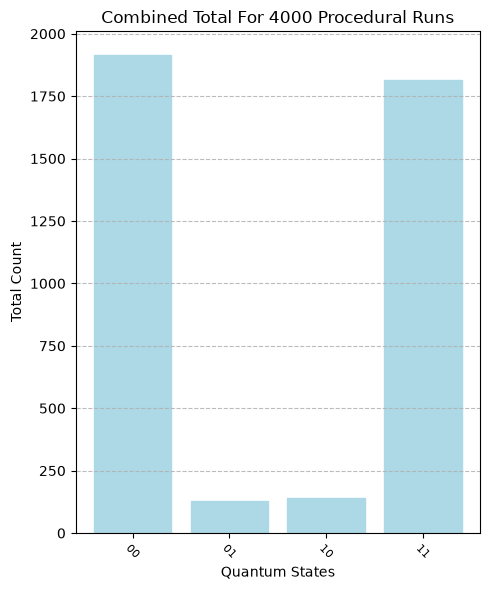

In [ ]:
total_counts.clear() #--- Reset the count
number_of_runs = 4000

for num in range(number_of_runs): #--- Run the following once per shot
  noisy_circuit = inject_errors(base_circuit) #--- Create the noisy_circuit
  final_circuit = create_final_circuit(base_circuit, find_errors()[0], find_errors()[1]) #--- Create a final circuit that models crosstalk | find_errors[0] creates list of flipped qubits, find_errors[1] creates list of noisy moments(slices)
  simulate(cirq.amplitude_damp(0.01)) #--- Simulate the final circuit | Set the type of noise inside the parenthesis

print(f'Circuit:\n{base_circuit}\n')
Graph() #--- Graph the results | Needs to be outside the run loop |